In [30]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText

import json

from corner import corner

from otter import Otter
import syncfit


In [2]:
otterpath = os.path.join(os.getcwd(), "private_otter_data")
overwrite = False

radio_phot = pd.read_csv("ecle-photometry.csv")
meta = pd.read_csv("ecle-metadata.csv")

if overwrite:

    wise_phot = pd.read_csv("data/wise-photometry.csv", index_col=0)
    
    wise_phot["date"] = wise_phot["date_mjd"]
    wise_phot["date_format"] = "mjd"
    wise_phot["filter_eff_units"] = wise_phot["filter_eff_unit"]
    
    if os.path.exists(otterpath):
        for file in glob.glob(os.path.join(otterpath, "*")):
            os.remove(file)
        os.rmdir(otterpath)


    private_data = Otter.from_csvs("ecle-metadata.csv", photfile="all-photometry.csv", local_outpath=otterpath)
else:
    private_data = Otter(
        url="http://localhost:8529",
        username="root",
        password="",
        datadir=otterpath,
        gen_summary=True
    )

In [3]:
radio = private_data.get_phot(
    names=meta.name.to_list(), 
    obs_type="radio", 
    query_private=True, 
    return_type="pandas",
    flux_unit="mJy",
    freq_unit="GHz"
)

/home/noahf/astro-otter/otter/src/otter/io/transient.py:880: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(
/home/noahf/astro-otter/otter/src/otter/io/transient.py:638: UserWarning: Unable to apply the source mapping because Cannot set a DataFrame with multiple columns to the single column human_readable_refs
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/noahf/astro-otter/otter/src/otter/io/transient.py:638: UserWarning: Unable to apply the source mapping because 'private'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/noahf/astro-otter/otter/src/otter/io/transient.py:638: UserWarning: Unable to apply the source mapping because 'private'
  warnings.warn(f"Unable to apply the source mapping because {exc}")
/home/noahf/astro-otter/otter/src/otter/io/transient.py:638: UserWarning: Unable to apply the source mapping because 'private'
  warnings.warn(f"Unable to apply the source mapping b

/home/noahf/astro-otter/otter/src/otter/io/transient.py:880: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(


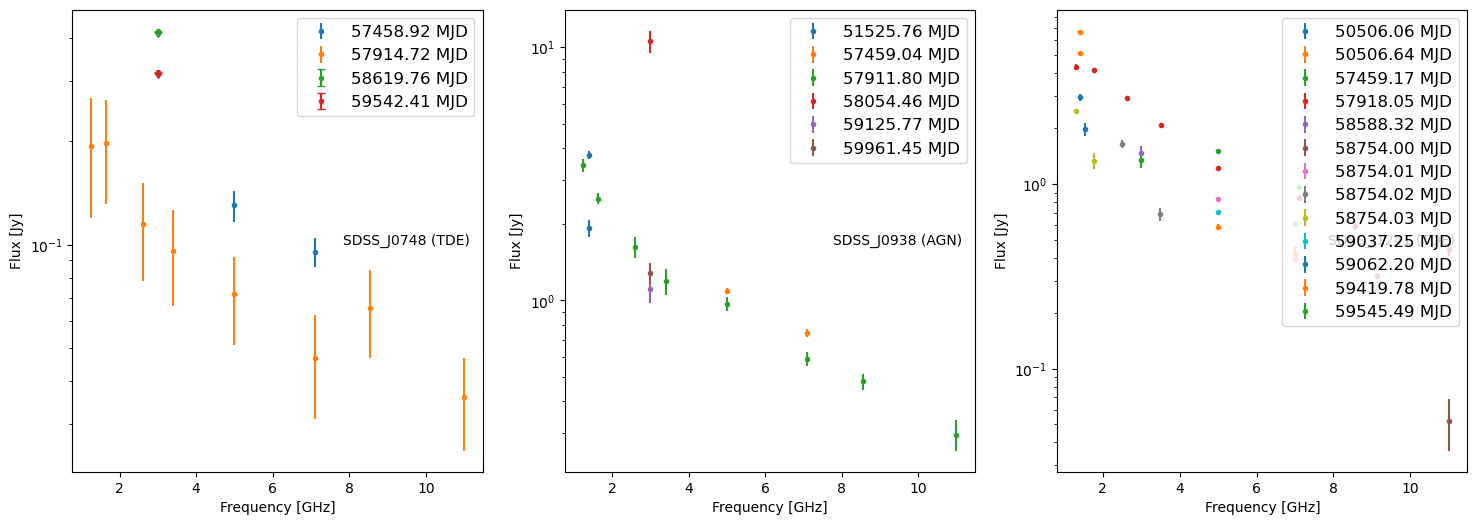

In [24]:
def choose_sideband_fullband(df):

    # need same time and same band name
    result = []
    for (t, band), grp in df.groupby(["converted_date", "filter_name"]):

        if len(grp) < 3:
            # this means that it is either full or side band, not both
            for _,row in grp.iterrows():
                result.append(row)
            continue
        
        # now of these we need to choose side band if both are not upperlimits
        # and full band if either (or both) is an upperlimit

        # sorting by the converted_frequency will tell us if it is a sideband or full band
        grp = grp.sort_values("converted_freq").reset_index()

        sideband_low = grp.iloc[0]
        sideband_high = grp.iloc[-1]
        fullband = grp.iloc[1] # assume that each is only three long

        if sideband_low.upperlimit or sideband_high.upperlimit:
            # then append the fullband
            result.append(fullband)
        else:
            result.append(sideband_low)
            result.append(sideband_high)

    res = pd.DataFrame(result).reset_index()
    return res

def make_sed(tde_name, ax, filter_sidebands=True):
    classes = private_data.query(names=tde_name, query_private=True)[0]['classification']
    for c in classes:
        if c['object_class'] in {'AGN', 'TDE'}:
            break
    ecle_class = c['object_class']

    df = radio[radio.name == tde_name]
    if filter_sidebands:
        df = choose_sideband_fullband(df)

    
    for label, grp in df.groupby('converted_date'):

        ax.errorbar(
            grp.converted_freq, 
            grp.converted_flux,
            fmt='o',
            markersize=3,
            yerr=grp.converted_flux_err,
            label=f'{label:.2f} MJD',
            uplims=grp.upperlimit
        )

        # next(ax._get_lines.prop_cycler)['color']


    ax.set_ylabel('Flux [Jy]')
    ax.set_xlabel('Frequency [GHz]')
    ax.set_yscale('log')

    at = AnchoredText(f'{tde_name} ({ecle_class})', 'center right', frameon=False)
    ax.add_artist(at)

    ax.legend(fontsize=12)
    
    return df
    
ecles_with_good_seds = ['SDSS_J0748','SDSS_J0938','SDSS_J1241']
fig, axs = plt.subplots(1,len(ecles_with_good_seds), figsize=(18,6))
                        
for ii, tde_name in enumerate(ecles_with_good_seds):
    make_sed(tde_name, axs[ii])

fig.savefig("good-radio-seds.png")

In [25]:
def plot_chains(chains_dict, labels=['p', 'log_F_nu', 'log_nu_a']):
    
    for k, c in chains_dict.items():
        corner(
            np.array(c),
            color="cornflowerblue",
            smooth=1,
            labels=labels,
            show_titles=True
        )

# SDSS J1241

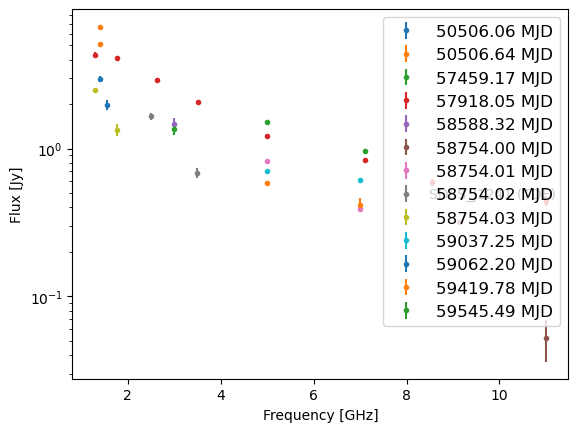

In [27]:
fig, ax = plt.subplots()
df = make_sed("SDSS_J1241", ax=ax)

16175it [02:15, 119.07it/s, batch: 8 | bound: 7 | nc: 1 | ncall: 78277 | eff(%): 20.513 | loglstar: -4.697 < -0.002 < -0.488 | logz: -9.782 +/-  0.076 | stop:  0.918]                 
18241it [01:37, 186.76it/s, batch: 7 | bound: 4 | nc: 1 | ncall: 56694 | eff(%): 32.033 | loglstar: -9.534 < -4.240 < -5.356 | logz: -17.881 +/-  0.094 | stop:  0.869]                 
18327it [01:49, 167.19it/s, batch: 6 | bound: 6 | nc: 1 | ncall: 62027 | eff(%): 29.332 | loglstar: -174.279 < -168.703 < -170.052 | logz: -184.541 +/-  0.108 | stop:  0.923]            
15888it [03:24, 77.87it/s, batch: 8 | bound: 11 | nc: 1 | ncall: 104031 | eff(%): 15.025 | loglstar: -12.057 < -7.178 < -7.731 | logz: -15.842 +/-  0.071 | stop:  0.895]                 
14606it [02:35, 93.70it/s, batch: 7 | bound: 10 | nc: 1 | ncall: 66475 | eff(%): 21.007 | loglstar: -6.173 < -1.191 < -1.547 | logz: -9.615 +/-  0.076 | stop:  0.985]                 


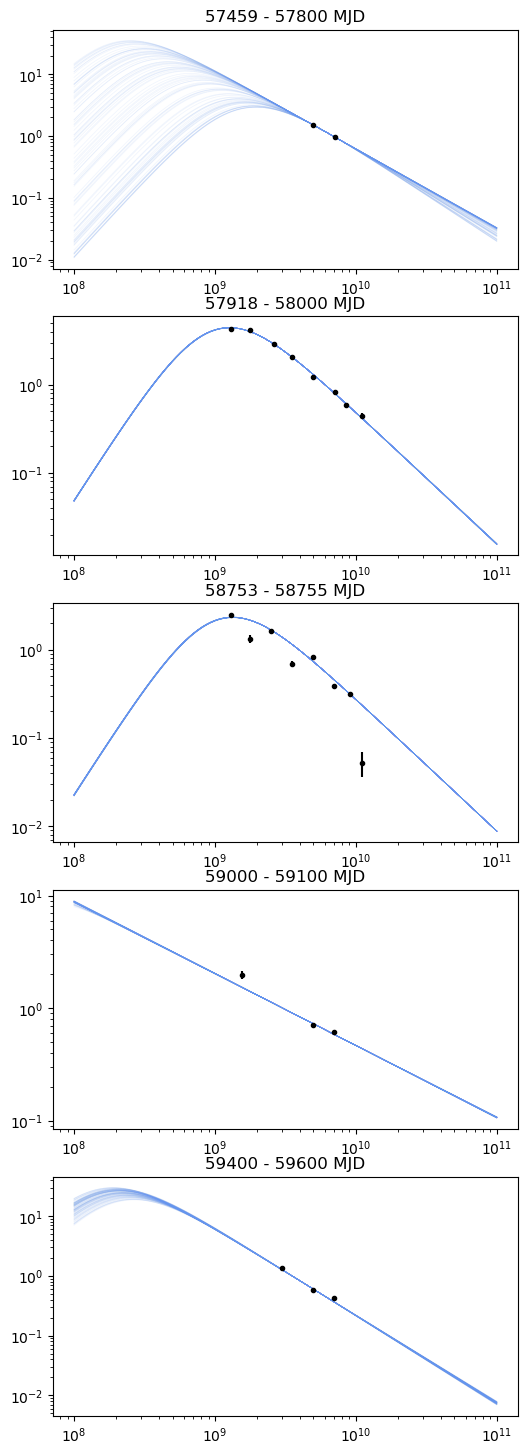

In [28]:
date_ranges = [
    # (50506, 50507),
    (57459, 57800), 
    (57918, 58000),
    # (58580, 58590),
    (58753, 58755),
    (59000, 59100),
    (59400, 59600)
]

nkeep = 100

results = []

chains = {}

fig, axs = plt.subplots(5,1, figsize=(6,18))
for r, ax in zip(date_ranges, axs):
    data = df[(df.converted_date > r[0]) * (df.converted_date < r[1])]
    ax.errorbar(
        data.converted_freq*1e9, 
        data.converted_flux,
        fmt='o',
        markersize=3,
        yerr=data.converted_flux_err,
        label=f'{r[0]} - {r[1]} MJD',
        uplims=data.upperlimit,
        color='k'
    )
    
    ax.set_yscale("log")
    ax.set_xscale("log")

    # ax.legend();
    ax.set_title(f'{r[0]} - {r[1]} MJD')
    
    try:
        model, sampler = syncfit.do_dynesty(
            F_mJy = data.converted_flux,
            F_error=data.converted_flux_err,
            nu=data.converted_freq,
            model=syncfit.models.B5,
            upperlimits=data.upperlimit
        )
    except RuntimeError:
        continue # this means it couldn't fit it...
    
    results.append((model, sampler))
    
    flat_samples, log_prob = syncfit.analysis.util.extract_output(sampler)

    chains[f"{(r[1]+r[0])/2}"] = flat_samples.tolist()
    
    nkeep = 100
    toplot = flat_samples[-nkeep:]
    nu_plot = np.logspace(8,11,100)
    for val in toplot:
        packed_theta = model.pack_theta(val)
        res = model.SED(nu_plot, **packed_theta)

        ax.plot(nu_plot, res,
                '-', color='cornflowerblue', lw = 0.5, alpha = 0.1)
        
with open("SDSSJ1241-radio-chains.json", "w") as f:
    json.dump(chains, f)
fig.savefig("SDSSJ1241-radio-fits.png")

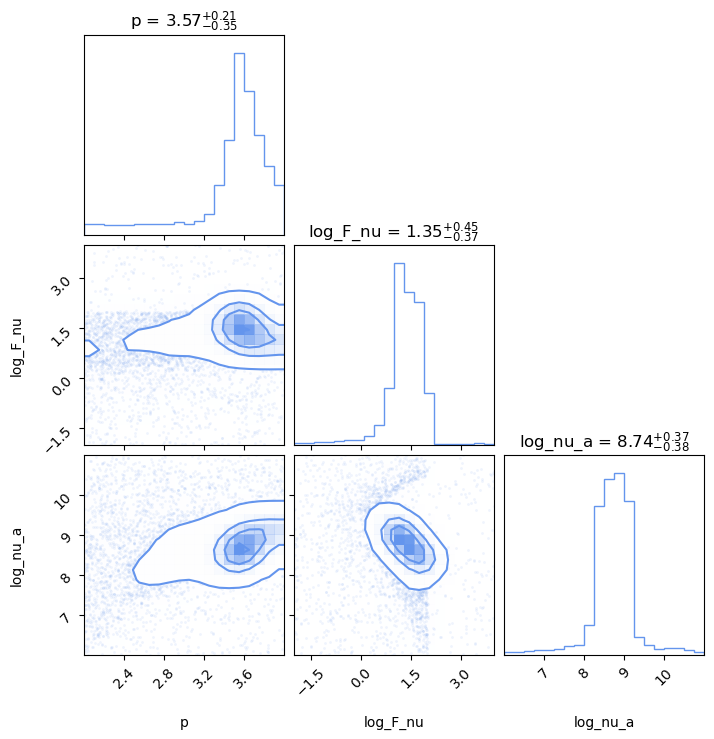

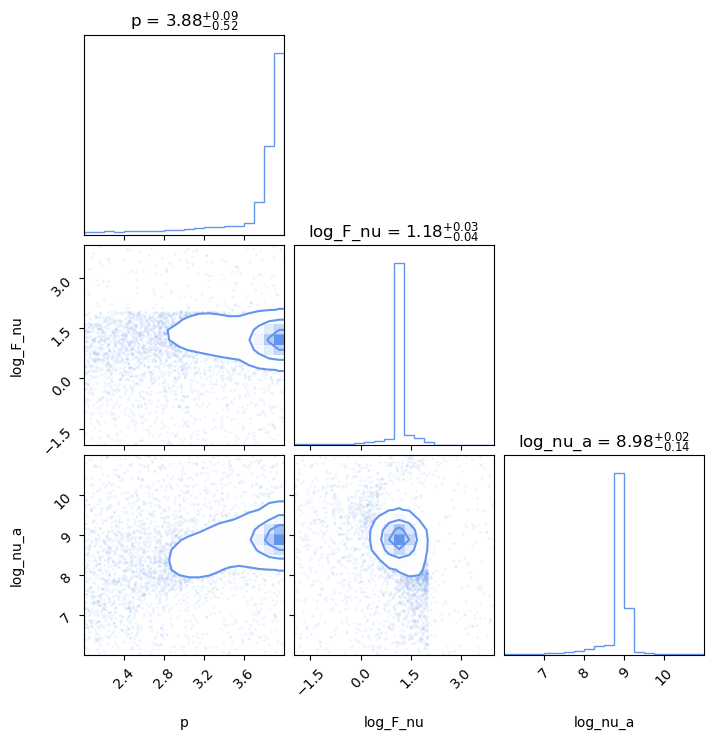

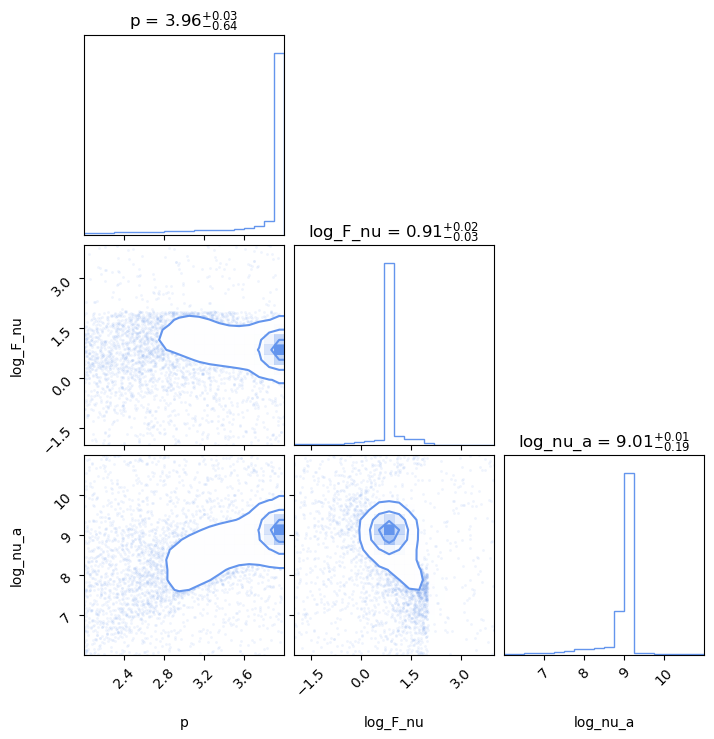

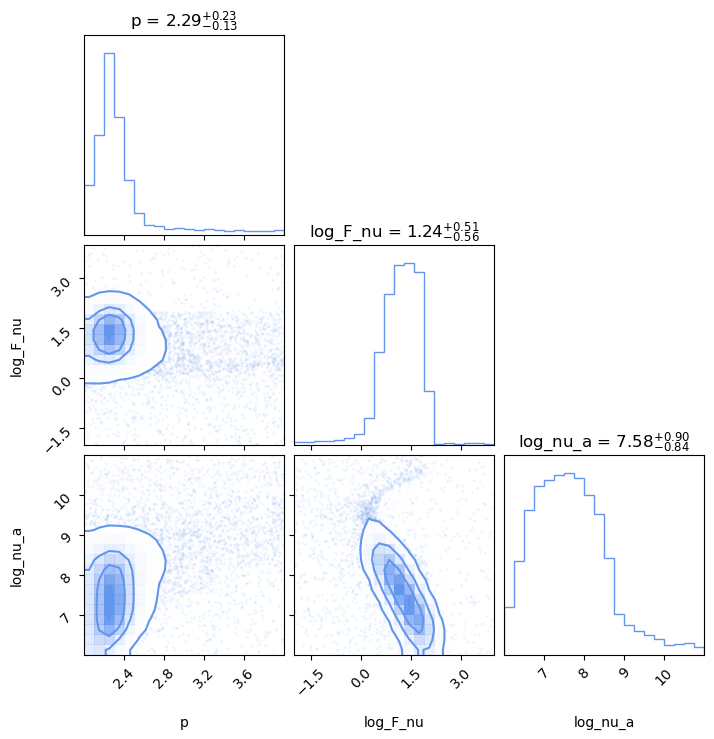

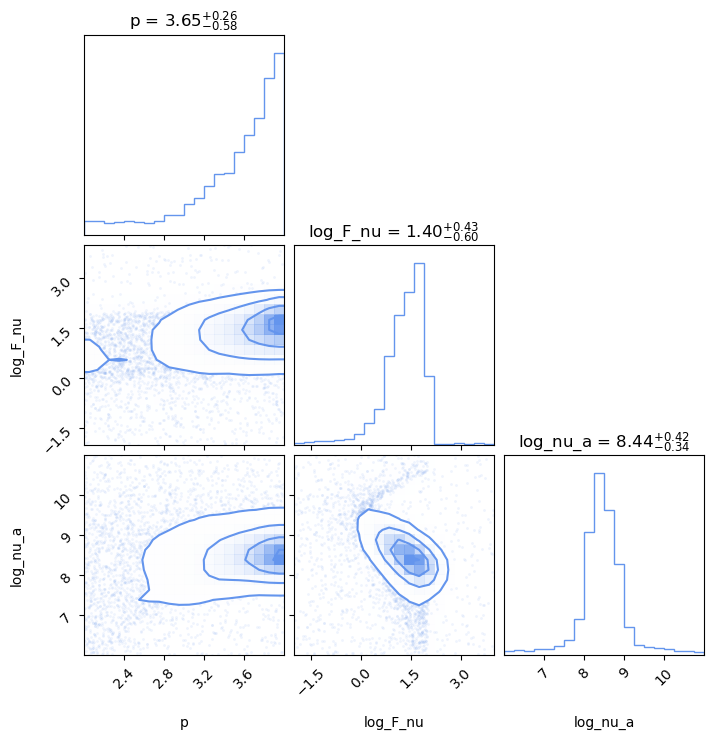

In [31]:
plot_chains(chains)

# SDSSJ0748

/home/noahf/astro-otter/otter/src/otter/io/transient.py:880: UserWarning: Names have the same score! Just using the existing default_name
  warnings.warn(


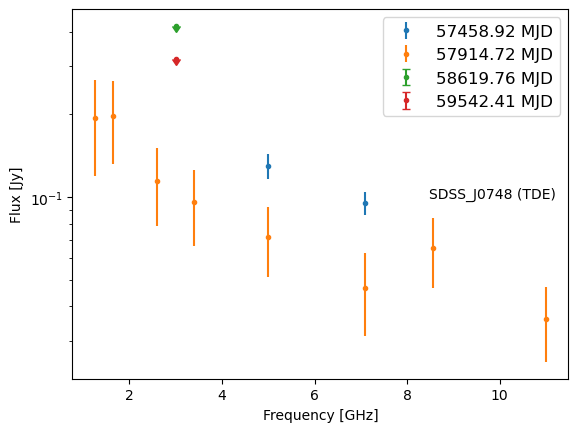

In [32]:
fig, ax = plt.subplots()
df = make_sed("SDSS_J0748", ax=ax)

   level_0  index        name  converted_flux  converted_flux_err  \
0        0    0.0  SDSS_J0748          0.1303              0.0135   
1        2    2.0  SDSS_J0748          0.0954              0.0092   

   converted_date  converted_wave  converted_freq converted_flux_unit  \
0      57458.9162    5.997049e+07           4.999                 mJy   
1      57458.9162    4.223024e+07           7.099                 mJy   

  converted_date_unit converted_wave_unit converted_freq_unit filter_name  \
0                 MJD                  nm                 GHz           C   
1                 MJD                  nm                 GHz           C   

  obs_type  upperlimit reference human_readable_refs  telescope  
0    radio       False   private             private        NaN  
1    radio       False   private             private        NaN  


14132it [02:49, 83.47it/s, batch: 9 | bound: 9 | nc: 1 | ncall: 91026 | eff(%): 15.245 | loglstar: -5.039 < -0.001 < -0.266 | logz: -5.145 +/-  0.052 | stop:  0.941]                     


   level_0  index        name  converted_flux  converted_flux_err  \
2        0    1.0  SDSS_J0748          0.0716              0.0206   
3        2    3.0  SDSS_J0748          0.0468              0.0157   
4        0    5.0  SDSS_J0748          0.1934              0.0739   
5        2    6.0  SDSS_J0748          0.1977              0.0661   
6        0    8.0  SDSS_J0748          0.1148              0.0366   
7        2    9.0  SDSS_J0748          0.0960              0.0299   
8        0   12.0  SDSS_J0748          0.0654              0.0187   
9        2   13.0  SDSS_J0748          0.0360              0.0109   

   converted_date  converted_wave  converted_freq converted_flux_unit  \
2     57914.71674    5.997049e+07           4.999                 mJy   
3     57914.71674    4.223024e+07           7.099                 mJy   
4     57914.71674    2.388785e+08           1.255                 mJy   
5     57914.71674    1.823555e+08           1.644                 mJy   
6     57914.7

14125it [01:52, 125.99it/s, batch: 8 | bound: 7 | nc: 1 | ncall: 58944 | eff(%): 23.731 | loglstar: -6.048 < -0.748 < -1.168 | logz: -6.033 +/-  0.054 | stop:  0.919]                 


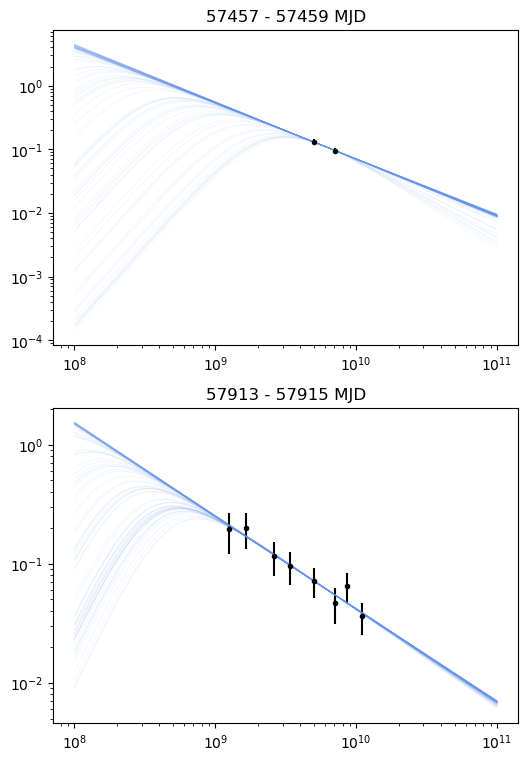

In [33]:
date_ranges = [
    (57457, 57459),
    (57913, 57915)
]

nkeep = 100

results = []
chains = {}

fig, axs = plt.subplots(len(date_ranges),1, figsize=(6,9))
for r, ax in zip(date_ranges, axs):
    data = df[(df.converted_date > r[0]) * (df.converted_date < r[1])]
    print(data)
    ax.errorbar(
        data.converted_freq*1e9, 
        data.converted_flux,
        fmt='o',
        markersize=3,
        yerr=data.converted_flux_err,
        label=f'{r[0]} - {r[1]} MJD',
        uplims=data.upperlimit,
        color='k'
    )
    
    ax.set_yscale("log")
    ax.set_xscale("log")

    # ax.legend();
    ax.set_title(f'{r[0]} - {r[1]} MJD')
    
    try:
        model, sampler = syncfit.do_dynesty(
            F_mJy = data.converted_flux,
            F_error=data.converted_flux_err,
            nu=data.converted_freq,
            model=syncfit.models.B5,
            upperlimits=data.upperlimit
        )
    except RuntimeError:
        continue # this means it couldn't fit it...
    
    results.append((model, sampler))
    
    flat_samples, log_prob = syncfit.analysis.util.extract_output(sampler)

    chains[f"{(r[1]+r[0])/2}"] = flat_samples.tolist()
    
    toplot = flat_samples[-nkeep:]
    nu_plot = np.logspace(8,11,100)
    for val in toplot:
        packed_theta = model.pack_theta(val)
        res = model.SED(nu_plot, **packed_theta)

        ax.plot(nu_plot, res,
                '-', color='cornflowerblue', lw = 0.5, alpha = 0.1)

with open("SDSSJ0748-radio-chains.json", "w") as f:
    json.dump(chains, f)
fig.savefig("SDSSJ0748-radio-fits.png")

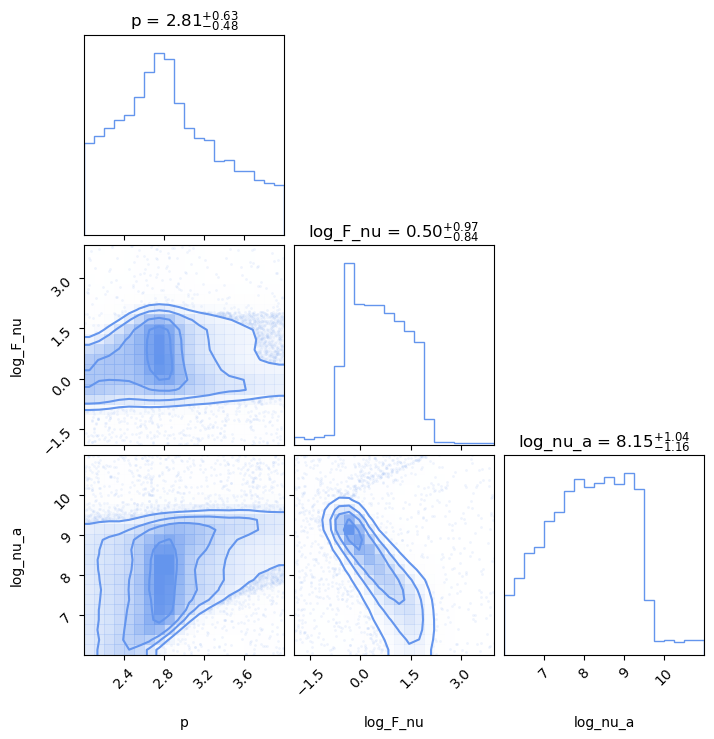

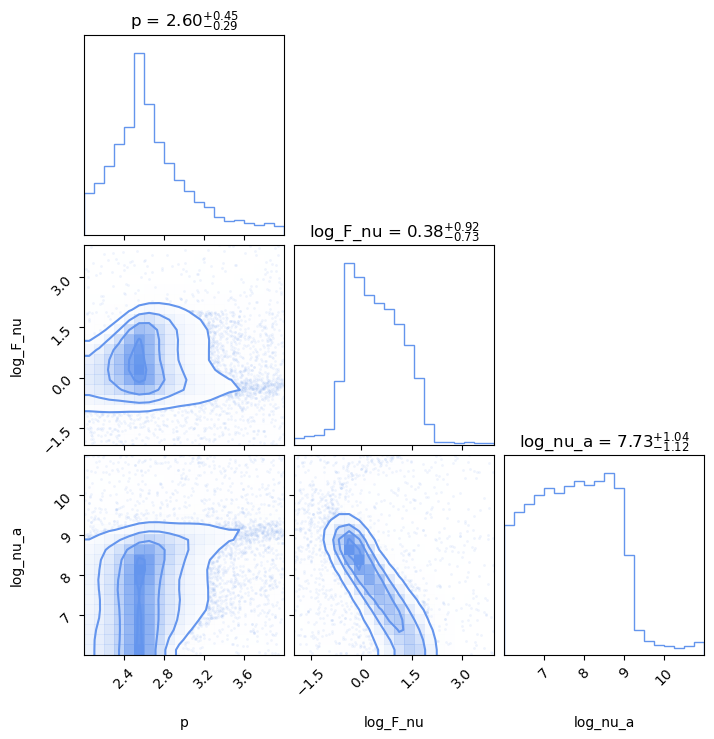

In [34]:
plot_chains(chains)

# SDSS J0938

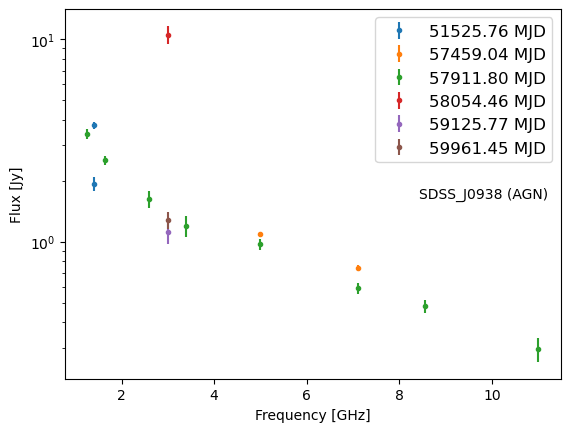

In [35]:
fig, ax = plt.subplots()
df = make_sed("SDSS_J0938", ax=ax)

   level_0        name  converted_flux  converted_flux_err  converted_date  \
2        0  SDSS_J0938          1.0924              0.0283     57459.04178   
3        2  SDSS_J0938          0.7453              0.0255     57459.04178   

   converted_wave  converted_freq converted_flux_unit converted_date_unit  \
2    5.997049e+07           4.999                 mJy                 MJD   
3    4.223024e+07           7.099                 mJy                 MJD   

  converted_wave_unit converted_freq_unit filter_name obs_type  upperlimit  \
2                  nm                 GHz           C    radio       False   
3                  nm                 GHz           C    radio       False   

  reference human_readable_refs  telescope  index  
2   private             private        NaN    0.0  
3   private             private        NaN    2.0  


14362it [03:16, 73.09it/s, batch: 7 | bound: 12 | nc: 1 | ncall: 99508 | eff(%): 12.334 | loglstar: -4.667 < -0.003 < -0.569 | logz: -7.991 +/-  0.072 | stop:  0.991]                 

    level_0        name  converted_flux  converted_flux_err  converted_date  \
4         0  SDSS_J0938          0.9706              0.0585     57911.79545   
5         2  SDSS_J0938          0.5897              0.0379     57911.79545   
6         0  SDSS_J0938          3.4218              0.1963     57911.79545   
7         2  SDSS_J0938          2.5266              0.1309     57911.79545   
8         0  SDSS_J0938          1.6291              0.1597     57911.79545   
9         2  SDSS_J0938          1.1919              0.1417     57911.79545   
10        0  SDSS_J0938          0.4793              0.0353     57911.79545   
11        2  SDSS_J0938          0.2954              0.0404     57911.79545   

    converted_wave  converted_freq converted_flux_unit converted_date_unit  \
4     5.997049e+07           4.999                 mJy                 MJD   
5     4.223024e+07           7.099                 mJy                 MJD   
6     2.388785e+08           1.255                 mJy


16582it [01:42, 161.21it/s, batch: 8 | bound: 7 | nc: 1 | ncall: 63673 | eff(%): 25.681 | loglstar: -9.572 < -4.384 < -4.982 | logz: -14.081 +/-  0.076 | stop:  0.868]                


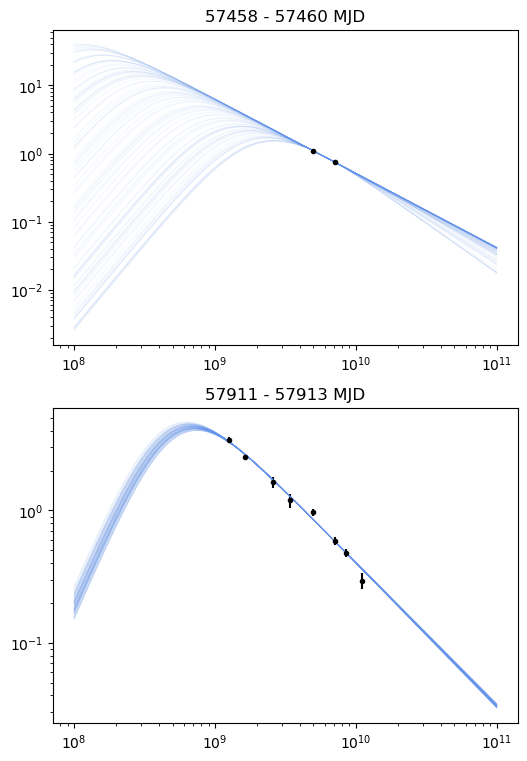

In [36]:
date_ranges = [
    (57458, 57460),
    (57911, 57913)
]

nkeep = 100

chains = {}

results = []

fig, axs = plt.subplots(len(date_ranges),1, figsize=(6,9))
for r, ax in zip(date_ranges, axs):
    data = df[(df.converted_date > r[0]) * (df.converted_date < r[1])]
    print(data)
    ax.errorbar(
        data.converted_freq*1e9, 
        data.converted_flux,
        fmt='o',
        markersize=3,
        yerr=data.converted_flux_err,
        label=f'{r[0]} - {r[1]} MJD',
        uplims=data.upperlimit,
        color='k'
    )
    
    ax.set_yscale("log")
    ax.set_xscale("log")

    # ax.legend();
    ax.set_title(f'{r[0]} - {r[1]} MJD')
    
    try:
        model, sampler = syncfit.do_dynesty(
            F_mJy = data.converted_flux,
            F_error=data.converted_flux_err,
            nu=data.converted_freq,
            model=syncfit.models.B5,
            upperlimits=data.upperlimit
        )
    except RuntimeError:
        continue # this means it couldn't fit it...
    
    results.append((model, sampler))
    
    flat_samples, log_prob = syncfit.analysis.util.extract_output(sampler)

    chains[f"{(r[1]+r[0])/2}"] = flat_samples.tolist()
    
    toplot = flat_samples[-nkeep:]
    nu_plot = np.logspace(8,11,100)
    for val in toplot:
        packed_theta = model.pack_theta(val)
        res = model.SED(nu_plot, **packed_theta)

        ax.plot(nu_plot, res,
                '-', color='cornflowerblue', lw = 0.5, alpha = 0.1)
        
with open("SDSSJ0938-radio-chains.json", "w") as f:
    json.dump(chains, f) 
fig.savefig("SDSSJ0938-radio-fits.png")

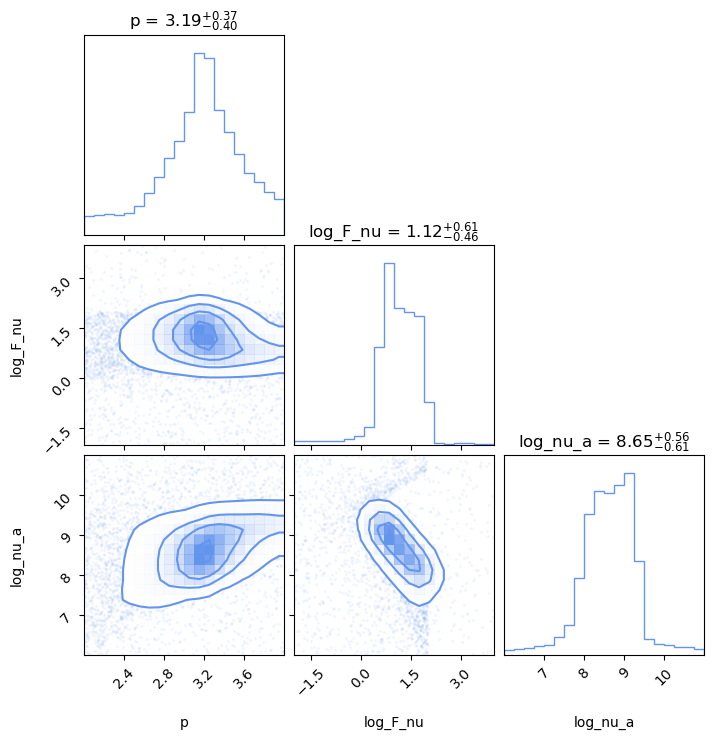

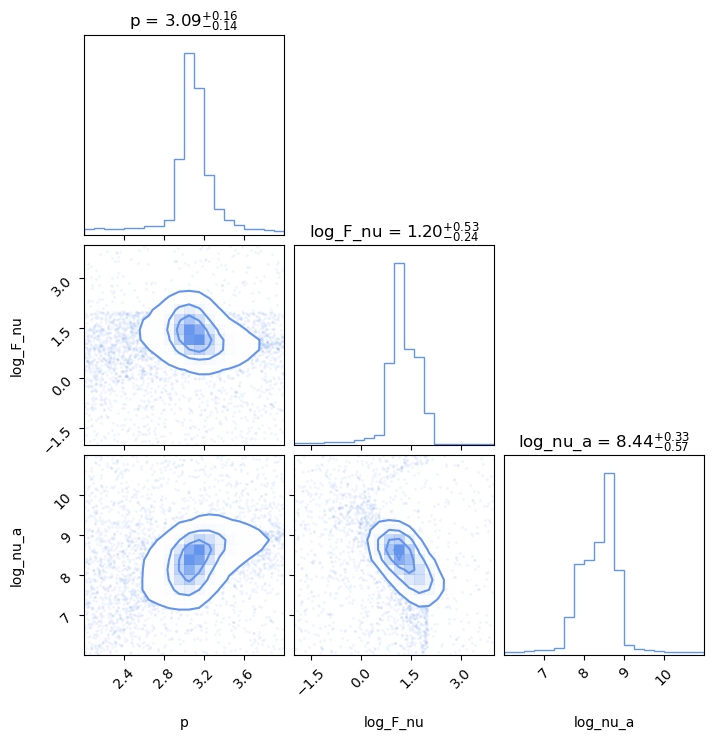

In [37]:
plot_chains(chains)